In [34]:
# Objective:
# Build and compare three approaches (Zero-Shot, Few-Shot, Fine-Tuned) for automatic support ticket tagging into 8 categories using BART-large-MNLI for zero/few-shot inference and DistilBERT for fine-tuned classification
# Evaluate performance metrics, visualize comparisons, and deploy an interactive Gradio app for real-time ticket classification.
# URL: https://a7708614ff29444d78.gradio.live

In [3]:
# Environment Setup & GPU Check
# ── Install all required packages ──────────────────────────────────────────
!pip install -q transformers==4.44.2 datasets accelerate evaluate gradio \
              scikit-learn pandas numpy matplotlib sentencepiece \
              protobuf seqeval peft

import importlib, sys
# Remove any cached transformers modules so fresh version loads
mods_to_remove = [k for k in sys.modules if 'transformers' in k]
for m in mods_to_remove:
    del sys.modules[m]

print("✅ Done!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 809.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 27.0 MB/s eta 0:00:00
✅ Done!


In [4]:
# ── GPU and Device Check ─────────────────────────────────────────────────────
import torch
# Determine available compute device (CUDA GPU or CPU fallback)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device : {device}")

# If GPU is available, display detailed hardware information
if device == "cuda":
    print(f"🔥 GPU    : {torch.cuda.get_device_name(0)}")  # GPU model name (e.g., Tesla T4, V100)
    print(f"💾 VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")  # Convert bytes to GB
else:
    # Provide instructions for enabling GPU in Google Colab
    print("⚠️  No GPU detected — Runtime → Change runtime type → T4 GPU")

🖥️  Device : cpu
⚠️  No GPU detected — Runtime → Change runtime type → T4 GPU


In [5]:
# ── Global Imports ─────────────────────────────────────────────────────────
import os, re, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Scikit-learn imports for preprocessing and evaluation
from sklearn.preprocessing import LabelEncoder  # Convert text labels to numeric IDs
from sklearn.model_selection import train_test_split  # Create train/val/test splits
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)  # Comprehensive evaluation metrics

# HuggingFace Transformers imports for NLP models
from transformers import (
    pipeline,  # Easy inference pipeline
    AutoTokenizer,  # Automatic tokenizer loading
    AutoModelForSequenceClassification,  # Pre-trained models with classification head
    TrainingArguments,  # Training configuration
    Trainer,  # Main training loop
    DataCollatorWithPadding,  # Dynamic padding for batches
    set_seed  # Set all random seeds
)
from datasets import Dataset, DatasetDict  # HuggingFace dataset utilities
import evaluate  # Evaluation metrics library

# Suppress warning messages for cleaner output
warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────
# Set all random seeds to ensure results are identical across runs
SEED = 42
set_seed(SEED)  # Transformers seed
random.seed(SEED)  # Python random seed
np.random.seed(SEED)  # NumPy random seed

print("✅ Imports successful | Seed set to", SEED)

✅ Imports successful | Seed set to 42


In [8]:
# Dataset Creation & Preprocessing
# ── Synthetic Dataset Generator ────────────────────────────────────────────
# 8 realistic support categories with 30 tickets each → 240 total samples
CATEGORIES = [
    "Billing", "Technical Issue", "Login Problem",
    "Account Access", "Refund", "Shipping",
    "Cancellation", "Product Inquiry"
]

# Template messages for each category (30 realistic tickets per category = 240 total samples)
# Each template mimics real customer support queries users might submit
TEMPLATES = {
    "Billing": [
        "I was charged twice for my subscription this month, please help.",
        "My invoice shows an incorrect amount, I need this corrected.",
        "Why was I charged before the billing date?",
        "I need a copy of my last billing statement urgently.",
        "There is an unauthorized charge on my credit card from your company.",
        "My payment failed but money was deducted from my account.",
        "Can I change my billing cycle from monthly to annual?",
        "I never received a receipt for my last payment.",
        "My VAT invoice has incorrect details, please update.",
        "I was billed for a service I cancelled last month.",
        "How do I update my payment method to a new card?",
        "My promo discount was not applied during checkout.",
        "The system charged me in USD but I should be billed in EUR.",
        "I need an official invoice for company reimbursement.",
        "My subscription renewed automatically even after I cancelled.",
        "I see a pending transaction that I did not authorize.",
        "Please send me a breakdown of all charges this quarter.",
        "Why did my plan price increase without any notice?",
        "My credit card was declined even though it has sufficient balance.",
        "I have been billed for three months but only used the service for one.",
        "How do I apply a voucher code to my next invoice?",
        "My annual plan was renewed at full price despite the discount offer.",
        "I want to dispute a charge that appeared on my statement.",
        "The billing address on my account is outdated, please correct it.",
        "I received two invoices for the same order, which one is correct?",
        "My PayPal payment was successful but the order is still pending.",
        "I need a tax exemption certificate applied to my account.",
        "My bank says the transaction failed but I am still charged.",
        "Can I split my payment across two credit cards?",
        "Please explain the extra processing fee on my last invoice."
    ],
    "Technical Issue": [
        "The app keeps crashing every time I open it on my iPhone.",
        "I get a 500 internal server error when submitting the form.",
        "The dashboard is not loading any data since this morning.",
        "Videos are not playing and showing a black screen.",
        "The export to PDF feature is completely broken.",
        "I receive error code 403 when accessing the API.",
        "The mobile app is extremely slow and takes forever to load.",
        "File uploads fail consistently above 5MB.",
        "Notifications are not being delivered to my email.",
        "The search functionality returns no results for any keyword.",
        "Two-factor authentication SMS is not arriving on my phone.",
        "The browser extension is not compatible with Chrome version 124.",
        "I cannot download my data even after multiple attempts.",
        "The sync between desktop and mobile is completely out of sync.",
        "I see a white blank screen after logging in on Windows.",
        "The integration with Slack stopped working after the last update.",
        "My account shows usage data from another user, possible data leak.",
        "Audio is distorted during live session calls.",
        "The print function in the web app is not working.",
        "API rate limits are being hit even under normal usage.",
        "Charts and graphs in reports are not rendering correctly.",
        "The dark mode setting resets itself every time I log out.",
        "I cannot attach files in the support chat widget.",
        "The page keeps redirecting in an infinite loop on Safari.",
        "My calendar events are duplicated after syncing with Google Calendar.",
        "The webhook is not firing even though the configuration looks correct.",
        "I get a CORS error when making API calls from my application.",
        "The bulk import feature fails with a cryptic error message.",
        "Images uploaded by users are not displaying in the feed.",
        "The map widget is not showing my location correctly."
    ],
    "Login Problem": [
        "I forgot my password and the reset email never arrived.",
        "My account has been locked after too many failed login attempts.",
        "I cannot log in even after resetting my password successfully.",
        "The login page shows an error: invalid credentials, but they are correct.",
        "I am logged out automatically every few minutes.",
        "SSO login with Google is not working for my corporate account.",
        "I changed my email address but cannot log in with the new one.",
        "The magic link for login is expired before I can click it.",
        "I cannot access my account from a new device after verification.",
        "The remember me option is not working and I must log in every time.",
        "My account was disabled without any notification or reason.",
        "Login with Microsoft account fails with a token error.",
        "After updating my password, the old password still works.",
        "I receive a session expired message immediately after logging in.",
        "Two-factor authentication code is not accepted even though it is correct.",
        "The login button is greyed out and unclickable on Firefox.",
        "I cannot log in from my country, it might be geo-restricted.",
        "My username was changed without my permission.",
        "The CAPTCHA at login is not loading properly.",
        "I get redirected to a 404 page after entering login credentials.",
        "My account shows as inactive even though I paid the subscription.",
        "Login via Apple ID is broken on the mobile app.",
        "I cannot recover my account because the recovery phone is outdated.",
        "My password manager autofill is not working with your login page.",
        "Login attempts from a new IP are being blocked without explanation.",
        "After clearing browser cache the login form no longer works.",
        "I am stuck in a redirect loop when trying to access my dashboard.",
        "The forgot password page just shows a spinner and never loads.",
        "I cannot link my Facebook account for social login.",
        "The login OTP is being sent to an old email I no longer have access to."
    ],
    "Account Access": [
        "I need to transfer ownership of my account to a colleague.",
        "My team member cannot be added to the organization account.",
        "I was accidentally removed as an admin from my own account.",
        "How do I merge two separate accounts into one?",
        "My account permissions changed without my approval.",
        "I need to grant read-only access to an external auditor.",
        "My account was deleted but I never requested that.",
        "How do I reactivate a suspended account?",
        "I cannot add more than five users to my business account.",
        "The account roles and permissions page is showing incorrectly.",
        "I need to downgrade my account but cannot find the option.",
        "My old employer still has access to my personal account data.",
        "How do I completely delete all my data from your platform?",
        "I want to give a freelancer temporary access without full permissions.",
        "My account is showing a different plan than what I purchased.",
        "I need to recover content from a deleted sub-account.",
        "How do I set up single sign-on for my enterprise team?",
        "My account dashboard shows data from a completely different user.",
        "I need to update the email address associated with my main account.",
        "My company account is inaccessible after the admin left the company.",
        "I need an audit log of all actions performed on my account.",
        "How do I enable two-factor authentication for all team members?",
        "I was charged for seats that are not assigned to any users.",
        "My account is flagged for suspicious activity but everything is normal.",
        "I need to set up IP whitelisting for our office network.",
        "How do I export all user data for compliance purposes?",
        "I cannot see historical data after upgrading my plan.",
        "My account shows as verified but features are still restricted.",
        "I want to separate my personal and business account profiles.",
        "The account creation form rejects my valid business email domain."
    ],
    "Refund": [
        "I want a full refund for my purchase made three days ago.",
        "The product I received is damaged and I am requesting a refund.",
        "I was charged after cancelling my subscription, please refund.",
        "How long does a refund typically take to process?",
        "I returned the item two weeks ago but still have not received my money back.",
        "My refund was partially processed but not the full amount.",
        "The service did not work as advertised and I want my money back.",
        "I accidentally purchased the wrong plan and need a refund.",
        "The event was cancelled and I want a refund for my ticket.",
        "I was denied a refund even though I am within the 30-day policy.",
        "My refund was issued to a card I no longer have access to.",
        "I need a refund for a duplicate order that was placed by mistake.",
        "The refund was processed but I see no credit on my statement.",
        "I subscribed by mistake and want an immediate refund.",
        "The digital product I purchased does not work and I want a refund.",
        "I am requesting a refund under the consumer protection laws.",
        "My refund request was ignored for over a week, please escalate.",
        "The course I purchased was not as described, requesting refund.",
        "I was charged a cancellation fee that was not disclosed upfront.",
        "Can I get store credit instead of a cash refund?",
        "My refund was issued to an expired PayPal account.",
        "The promotional price I was promised was not honoured at checkout.",
        "I need a refund because the order was delivered to the wrong address.",
        "The subscription auto-renewed while I was on vacation, please refund.",
        "I want a pro-rated refund for the unused portion of my annual plan.",
        "Your service was down for 3 days and I deserve a credit.",
        "The refund confirmation email never arrived after the agent promised it.",
        "I returned the device but only received a partial refund.",
        "Please refund the shipping cost since the delivery was extremely late.",
        "I purchased a gift subscription by mistake, please refund immediately."
    ],
    "Shipping": [
        "My order has not arrived even though it shows delivered.",
        "I need to change the delivery address for my pending order.",
        "The tracking number provided is not working on the courier website.",
        "My package was marked delivered but left outside in the rain.",
        "The estimated delivery date has passed and no update is given.",
        "I ordered express shipping but it is coming via standard delivery.",
        "My order was split into two shipments without notification.",
        "The courier attempted delivery but I was home all day.",
        "My package shows stuck in customs for over a week.",
        "I need to reschedule my delivery to a weekend date.",
        "The package was delivered to my neighbour without permission.",
        "I received an empty box with no products inside.",
        "Only half of my order was shipped, rest is missing.",
        "The delivery driver left my package in the wrong location.",
        "Can I pick up my order from the local warehouse instead?",
        "My international shipment has been in transit for 3 weeks.",
        "I was charged import duties that were not mentioned at checkout.",
        "The fragile items in my order arrived completely broken.",
        "I did not receive a shipping confirmation email after my order.",
        "My order was returned to sender without any delivery attempt.",
        "The package was significantly delayed due to wrong label.",
        "I want to add insurance to my pending shipment.",
        "My subscription box did not ship this month as expected.",
        "The courier says delivered but tracking shows still in transit.",
        "I need to intercept my package and redirect to a new address.",
        "Two items from my order shipped but one is still not dispatched.",
        "My package was lost and I need a replacement or refund.",
        "The delivery was attempted at the wrong address entirely.",
        "I need a signature waiver for my upcoming delivery.",
        "My order arrived without any packing slip or invoice."
    ],
    "Cancellation": [
        "I want to cancel my subscription effective immediately.",
        "How do I cancel my account without losing my data?",
        "I tried to cancel but the cancel button is not available.",
        "Please confirm that my subscription has been successfully cancelled.",
        "I cancelled my plan but was still charged for next month.",
        "I need to cancel my order before it ships.",
        "The cancellation confirmation email never arrived.",
        "I want to pause my subscription instead of cancelling completely.",
        "How do I cancel my free trial before it converts to paid?",
        "My cancellation request was processed but the account is still active.",
        "I am moving abroad and need to cancel all services.",
        "I want to cancel due to financial difficulties, any exceptions?",
        "The website makes it extremely difficult to find the cancellation option.",
        "I need to cancel a service on behalf of a deceased family member.",
        "Can I cancel mid-cycle and get a pro-rated refund?",
        "I cancelled via email but the account is still active after a week.",
        "I want to cancel and switch to a competitor plan.",
        "Please cancel all future orders on my account immediately.",
        "The cancellation took effect immediately even though I paid for the month.",
        "I want to cancel but retain access until end of current billing period.",
        "How do I cancel an addon service without cancelling my main plan?",
        "I was not informed of a cancellation fee when signing up.",
        "I cancelled on the app but desktop still shows active subscription.",
        "I want to cancel as the product features do not match what was advertised.",
        "My account was not cancelled despite multiple requests.",
        "Can you cancel and issue a full refund at the same time?",
        "The retention offer I was given is not compelling enough to stay.",
        "I need written confirmation of cancellation for legal purposes.",
        "How long after cancellation until my data is permanently deleted?",
        "I accidentally cancelled and need to immediately reactivate my account."
    ],
    "Product Inquiry": [
        "What is the difference between the basic and pro plan?",
        "Does your software support integration with Salesforce?",
        "Can I use the product offline without an internet connection?",
        "What are the system requirements for the desktop application?",
        "Is there a free trial available before I purchase?",
        "Do you offer educational discounts for students and teachers?",
        "How many users can I add to the enterprise plan?",
        "Does the product support GDPR compliance for European customers?",
        "What file formats are supported for data import and export?",
        "Is there a mobile app available for Android devices?",
        "Can I customise the branding and white-label the product?",
        "What languages does the platform support?",
        "How does your product compare to the competitor XYZ?",
        "Does the API support OAuth 2.0 authentication?",
        "What is the uptime SLA for the enterprise tier?",
        "Can I migrate data from my current platform easily?",
        "Is there a public changelog where I can see recent updates?",
        "Do you provide dedicated account manager for enterprise clients?",
        "What data backup and recovery options are available?",
        "Does your product have a feature for bulk user management?",
        "Is there a sandbox or testing environment I can use?",
        "How often are new features released and what is the roadmap?",
        "Does the platform support multi-currency transactions?",
        "Can I set up automated workflows without coding knowledge?",
        "What kind of customer support is included in each plan?",
        "Is there an open-source version or community edition available?",
        "Does the product work with screen readers for accessibility?",
        "Can multiple people work on the same document simultaneously?",
        "What encryption standards are used to protect my data?",
        "Is there a maximum storage limit on the business plan?"
    ]
}

# ── Build DataFrame ─────────────────────────────────────────────────────────
# Create list of dictionaries with text and label pairs
rows = []
for cat, texts in TEMPLATES.items():
    for text in texts:
        rows.append({"text": text, "label": cat})

# Convert to pandas DataFrame
df_raw = pd.DataFrame(rows)
# Shuffle randomly to avoid any ordering bias
df_raw = df_raw.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Display dataset statistics
print(f"✅ Dataset created: {len(df_raw)} samples | {df_raw['label'].nunique()} categories")
print("\n📊 Class distribution:")
print(df_raw['label'].value_counts())  # Should show 30 samples per category (balanced dataset)


✅ Dataset created: 240 samples | 8 categories

📊 Class distribution:
label
Billing            30
Account Access     30
Shipping           30
Product Inquiry    30
Login Problem      30
Refund             30
Technical Issue    30
Cancellation       30
Name: count, dtype: int64


In [9]:
# ── Label Encoding ──────────────────────────────────────────────────────────
# Initialize LabelEncoder to convert text categories to integers
le = LabelEncoder()
# Fit encoder on all unique labels and transform to numeric IDs (0 to N-1)
df_raw['label_id'] = le.fit_transform(df_raw['label'])

# Create mapping: ID → Label (e.g., 0 → "Account Access", 1 → "Billing", etc.)
id2label = {i: l for i, l in enumerate(le.classes_)}
# Create mapping: Label → ID (e.g., "Account Access" → 0, "Billing" → 1)
label2id = {l: i for i, l in id2label.items()}
# Total number of unique classes (should be 8)
NUM_LABELS = len(le.classes_)

# Display encoding results
print(f"✅ {NUM_LABELS} labels encoded")
print("Mapping:", id2label)  # Shows which number corresponds to which category

✅ 8 labels encoded
Mapping: {0: 'Account Access', 1: 'Billing', 2: 'Cancellation', 3: 'Login Problem', 4: 'Product Inquiry', 5: 'Refund', 6: 'Shipping', 7: 'Technical Issue'}


In [10]:
# ── Train / Validation / Test Split ────────────────────────────────────────
# 70% train | 15% val | 15% test
# Split dataset into train (70%), validation (15%), and test (15%) sets with class stratification

# First split: Separate 30% for temp (validation + test), keep 70% for training
df_train, df_temp = train_test_split(
    df_raw,
    test_size=0.30,           # 30% goes to temp set
    random_state=SEED,        # Reproducible split
    stratify=df_raw['label_id']  # Preserve class distribution across splits
)

# Second split: Divide temp set equally into validation (50% of temp) and test (50% of temp)
# Since temp is 30% of total, each becomes 15% of original dataset
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,           # Half of temp for test, half for validation
    random_state=SEED,
    stratify=df_temp['label_id']  # Maintain class balance in both sets
)

# Reset indices for clean, sequential numbering (0, 1, 2, ...)
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

# Display final dataset sizes (should be ~168 train, ~36 val, ~36 test for 240 total samples)
print(f"✅ Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

✅ Train: 168 | Val: 36 | Test: 36


In [11]:
# Zero-Shot Classification
# ── Load Zero-Shot Pipeline ─────────────────────────────────────────────────
# Zero-shot classification uses NLI (Natural Language Inference) to classify without training
# Model: BART-large fine-tuned on MNLI (Multi-Genre Natural Language Inference)

print("⏳ Loading facebook/bart-large-mnli ...")
zs_classifier = pipeline(
    "zero-shot-classification",  # Task type: classify text into custom categories
    model="facebook/bart-large-mnli",  # Pre-trained NLI model (~1.6GB download)
    device=0 if device == "cuda" else -1  # Use GPU (0) if available, else CPU (-1)
)
print("✅ Zero-shot model loaded!")

⏳ Loading facebook/bart-large-mnli ...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Zero-shot model loaded!


In [12]:
# ── Zero-Shot Prediction Function ───────────────────────────────────────────
# Use all 8 categories as candidate labels for classification
CANDIDATE_LABELS = list(le.classes_)  # ["Billing", "Technical Issue", "Login Problem", ...]

def zero_shot_predict(text: str, top_k: int = 3) -> dict:
    """Predict top-k categories for a support ticket using zero-shot."""
    result = zs_classifier(
        text,
        candidate_labels=CANDIDATE_LABELS,
        hypothesis_template="This support ticket is about {}."  # Template for NLI premise
    )
    return {
        "top_labels": result["labels"][:top_k],  # Top-k predicted categories
        "top_scores": result["scores"][:top_k],  # Confidence scores for each
        "predicted": result["labels"][0]          # Highest confidence prediction
    }

# ── Demo Single Prediction ──────────────────────────────────────────────────
# Test ticket about billing issue
sample_ticket = "I was charged twice this month and need an urgent refund."
pred = zero_shot_predict(sample_ticket)

# Display results with confidence percentages
print("\n📩 Ticket:", sample_ticket)
print("\n🏆 Top-3 Predictions:")
for i, (label, score) in enumerate(zip(pred['top_labels'], pred['top_scores']), 1):
    print(f"   {i}. {label:<20} {score:.2%}")  # Format as percentage


📩 Ticket: I was charged twice this month and need an urgent refund.

🏆 Top-3 Predictions:
   1. Billing              33.83%
   2. Refund               29.35%
   3. Cancellation         13.08%


In [13]:
# Diagnosing Columns
print(df_test.columns.tolist())
print(df_test.head(2))

['text', 'label', 'label_id']
                                                text           label  label_id
0  I purchased a gift subscription by mistake, pl...          Refund         5
1  How do I export all user data for compliance p...  Account Access         0


In [14]:
# Applying Clean Text
def clean_text(text: str) -> str:
    import re
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = text.lower()
    return text

df_test['clean_text']  = df_test['text'].apply(clean_text)
df_val['clean_text']   = df_val['text'].apply(clean_text)
df_train['clean_text'] = df_train['text'].apply(clean_text)
print("✅ clean_text column added")

✅ clean_text column added


In [15]:
# ── Evaluate Zero-Shot on Test Set ──────────────────────────────────────────
print("⏳ Running zero-shot evaluation on test set...")

# Store predictions and ground truth labels
zs_preds, zs_true = [], []
t0 = time.time()  # Start timer for inference speed measurement

# Iterate through each test sample
for _, row in df_test.iterrows():
    # Use cleaned text if available, otherwise fall back to raw text
    text = row.get('clean_text') if 'clean_text' in row else row.get('text', '')
    pred = zero_shot_predict(text, top_k=1)  # Get top prediction only
    zs_preds.append(pred['predicted'])  # Store predicted category
    zs_true.append(row['label'])        # Store true label

zs_time = time.time() - t0  # Total inference time

# Calculate comprehensive evaluation metrics
zs_acc  = accuracy_score(zs_true, zs_preds)  # Overall accuracy
zs_f1   = f1_score(zs_true, zs_preds, average='weighted', zero_division=0)  # Weighted F1
zs_prec = precision_score(zs_true, zs_preds, average='weighted', zero_division=0)  # Precision
zs_rec  = recall_score(zs_true, zs_preds, average='weighted', zero_division=0)  # Recall

# Display results
print(f"\n✅ Zero-Shot Evaluation Complete ({zs_time:.1f}s)")
print(f"   Accuracy  : {zs_acc:.4f}")
print(f"   F1-Score  : {zs_f1:.4f}")
print(f"   Precision : {zs_prec:.4f}")
print(f"   Recall    : {zs_rec:.4f}")
print(f"   Speed     : {len(df_test)/zs_time:.2f} samples/sec")  # Throughput

# Detailed per-class performance report
print("\n📋 Classification Report:")
print(classification_report(zs_true, zs_preds, zero_division=0))

⏳ Running zero-shot evaluation on test set...

✅ Zero-Shot Evaluation Complete (200.1s)
   Accuracy  : 0.6944
   F1-Score  : 0.6593
   Precision : 0.8285
   Recall    : 0.6944
   Speed     : 0.18 samples/sec

📋 Classification Report:
                 precision    recall  f1-score   support

 Account Access       0.43      0.75      0.55         4
        Billing       1.00      1.00      1.00         4
   Cancellation       0.83      1.00      0.91         5
  Login Problem       1.00      0.20      0.33         5
Product Inquiry       1.00      0.20      0.33         5
         Refund       1.00      0.50      0.67         4
       Shipping       0.83      1.00      0.91         5
Technical Issue       0.44      1.00      0.62         4

       accuracy                           0.69        36
      macro avg       0.82      0.71      0.66        36
   weighted avg       0.83      0.69      0.66        36



In [16]:
# ── Few-Shot: Enriched Hypothesis Templates ────────────────────────────────
# Give a richer description of each category in the hypothesis.
# This gives the model more semantic context per label.
# Define rich, descriptive phrases for each category (provides semantic context to the model)
FEW_SHOT_DESCRIPTIONS = {
    "Billing"         : "billing charges, invoices, payments, or subscription fees",
    "Technical Issue" : "software bugs, crashes, errors, or technical malfunctions",
    "Login Problem"   : "login failures, password resets, or authentication errors",
    "Account Access"  : "account permissions, ownership, access control, or account management",
    "Refund"          : "refund requests, money back, or reimbursement",
    "Shipping"        : "delivery, shipment tracking, or courier issues",
    "Cancellation"    : "cancelling subscriptions, orders, or service termination",
    "Product Inquiry" : "product features, pricing plans, or general product questions",
}

# Use descriptive phrases as candidate labels (instead of short category names)
ENRICHED_LABELS = list(FEW_SHOT_DESCRIPTIONS.values())
# Reverse mapping: description phrase → original category name
LABEL_FROM_DESC = {v: k for k, v in FEW_SHOT_DESCRIPTIONS.items()}

def few_shot_predict(text: str, top_k: int = 3) -> dict:
    """Few-shot classification using enriched label descriptions."""
    result = zs_classifier(
        text,
        candidate_labels=ENRICHED_LABELS,  # Pass descriptive phrases instead of short labels
        hypothesis_template="This customer support message is about {}."
    )
    top_labels_raw = result['labels'][:top_k]  # Get top-k descriptive phrases
    top_scores     = result['scores'][:top_k]   # Corresponding confidence scores
    top_labels     = [LABEL_FROM_DESC[l] for l in top_labels_raw]  # Convert back to original names
    return {
        "top_labels" : top_labels,
        "top_scores" : top_scores,
        "predicted"  : top_labels[0]
    }

# ── Demo ────────────────────────────────────────────────────────────────────
# Test the few-shot approach on the same billing ticket
pred_fs = few_shot_predict(sample_ticket)
print("📩 Ticket:", sample_ticket)
print("\n🏆 Few-Shot Top-3:")
for i, (label, score) in enumerate(zip(pred_fs['top_labels'], pred_fs['top_scores']), 1):
    print(f"   {i}. {label:<20} {score:.2%}")

📩 Ticket: I was charged twice this month and need an urgent refund.

🏆 Few-Shot Top-3:
   1. Refund               63.88%
   2. Billing              18.27%
   3. Account Access       5.70%


In [17]:
# ── Evaluate Few-Shot on Test Set ───────────────────────────────────────────
print("⏳ Running few-shot evaluation...")

# Store predictions and ground truth labels
fs_preds, fs_true = [], []
t0 = time.time()  # Start timer for performance measurement

# Iterate through each test sample
for _, row in df_test.iterrows():
    # Use cleaned text if available (preprocessed), otherwise fallback to raw text
    text = row.get('clean_text') if 'clean_text' in row else row.get('text', '')
    pred = few_shot_predict(text, top_k=1)  # Get only the top prediction
    fs_preds.append(pred['predicted'])  # Store predicted category
    fs_true.append(row['label'])        # Store true label

fs_time = time.time() - t0  # Calculate total inference time

# Calculate performance metrics for few-shot approach
fs_acc  = accuracy_score(fs_true, fs_preds)  # Overall accuracy
fs_f1   = f1_score(fs_true, fs_preds, average='weighted', zero_division=0)  # Weighted F1-score
fs_prec = precision_score(fs_true, fs_preds, average='weighted', zero_division=0)  # Precision
fs_rec  = recall_score(fs_true, fs_preds, average='weighted', zero_division=0)  # Recall

# Display results
print(f"\n✅ Few-Shot Evaluation Complete ({fs_time:.1f}s)")
print(f"   Accuracy  : {fs_acc:.4f}")
print(f"   F1-Score  : {fs_f1:.4f}")
print(f"   Precision : {fs_prec:.4f}")
print(f"   Recall    : {fs_rec:.4f}")

⏳ Running few-shot evaluation...

✅ Few-Shot Evaluation Complete (238.6s)
   Accuracy  : 0.5833
   F1-Score  : 0.5805
   Precision : 0.6894
   Recall    : 0.5833


In [18]:
# Fine-Tuning with DistilBERT
# ── Tokenizer ───────────────────────────────────────────────────────────────
# DistilBERT: 40% smaller than BERT, 60% faster, retains 97% accuracy
FT_MODEL_NAME = "distilbert-base-uncased"  # Uncased = lowercase all text
MAX_LEN       = 128   # Maximum sequence length (truncates longer texts to save memory on Colab)

print(f"⏳ Loading tokenizer: {FT_MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(FT_MODEL_NAME)  # Load DistilBERT's tokenizer

def tokenize_function(examples):
    """Convert text to token IDs with truncation but without padding (dynamic padding later)"""
    return tokenizer(
        examples["clean_text"],  # Use pre-cleaned ticket text
        truncation=True,         # Cut off text exceeding MAX_LEN
        padding=False,           # Don't pad now (DataCollatorWithPadding handles it dynamically for efficiency)
        max_length=MAX_LEN
    )

print("✅ Tokenizer ready")

⏳ Loading tokenizer: distilbert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer ready


In [19]:
# ── Build HuggingFace DatasetDict ───────────────────────────────────────────
def df_to_hf_dataset(df: pd.DataFrame) -> Dataset:
    """Convert pandas DataFrame to HuggingFace Dataset format."""
    return Dataset.from_dict({
        "clean_text": df['clean_text'].tolist(),  # Ticket text (features)
        "labels"    : df['label_id'].tolist()     # Numeric labels (target)
    })

# Create DatasetDict with train, validation, and test splits
hf_dataset = DatasetDict({
    "train" : df_to_hf_dataset(df_train),  # 70% of data
    "val"   : df_to_hf_dataset(df_val),    # 15% of data
    "test"  : df_to_hf_dataset(df_test)    # 15% of data
})

# ── Tokenize All Splits ─────────────────────────────────────────────────────
# Apply tokenization function to all splits in parallel
tokenized = hf_dataset.map(tokenize_function, batched=True)
# Remove raw text column (no longer needed after tokenization)
tokenized = tokenized.remove_columns(["clean_text"])
# Convert to PyTorch tensor format for efficient training
tokenized.set_format("torch")

# Data collator dynamically pads batches to the longest sequence in each batch
# This optimizes memory usage compared to padding all sequences to MAX_LEN
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Dataset tokenized and ready")
print(tokenized)  # Display dataset structure (columns, sizes, features)

Map:   0%|          | 0/168 [00:00<?, ? examples/s]

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

✅ Dataset tokenized and ready
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 168
    })
    val: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 36
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 36
    })
})


In [20]:
# ── Load DistilBERT for Classification ──────────────────────────────────────
print(f"⏳ Loading {FT_MODEL_NAME} for sequence classification...")
ft_model = AutoModelForSequenceClassification.from_pretrained(
    FT_MODEL_NAME,              # "distilbert-base-uncased" - pre-trained weights
    num_labels=NUM_LABELS,      # Number of output classes (8 categories)
    id2label=id2label,          # Mapping: index → label name (for interpretability)
    label2id=label2id           # Mapping: label name → index (for encoding)
)
# Display model size (DistilBERT has ~66M parameters vs BERT's ~110M)
print(f"✅ Model loaded | Parameters: {ft_model.num_parameters():,}")

⏳ Loading distilbert-base-uncased for sequence classification...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded | Parameters: 66,959,624


In [21]:
# ── Metrics Function ────────────────────────────────────────────────────────
# Load evaluation metrics from HuggingFace evaluate library
accuracy_metric = evaluate.load("accuracy")  # Simple accuracy: correct/total
f1_metric       = evaluate.load("f1")        # F1-score: harmonic mean of precision & recall

def compute_metrics(eval_pred):
    """Calculate accuracy and weighted F1-score from model predictions."""
    logits, labels = eval_pred  # Unpack predictions and ground truth
    predictions = np.argmax(logits, axis=-1)  # Convert logits to class indices (highest probability)

    # Compute metrics
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1  = f1_metric.compute(predictions=predictions, references=labels, average='weighted')

    # Return as dictionary (Trainer expects this format)
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

print("✅ Compute metrics function ready")

✅ Compute metrics function ready


In [22]:
# ── Training Arguments ─────────────────────
# Create output directory for model checkpoints (exists_ok=True prevents errors)
os.makedirs("/content/models/distilbert-support", exist_ok=True)

# Configure training hyperparameters for DistilBERT fine-tuning
training_args = TrainingArguments(
    output_dir                  = "/content/models/distilbert-support",  # Save checkpoints here
    num_train_epochs            = 15,  # Passes through entire dataset (increased for small dataset)
    per_device_train_batch_size = 8,   # Smaller batch to fit in Colab GPU memory (T4 has 15GB)
    per_device_eval_batch_size  = 16,  # Larger eval batch (no gradients, uses less memory)
    warmup_ratio                = 0.2,  # 20% steps for LR warmup (gradually increase learning rate)
    weight_decay                = 0.01,  # L2 regularization to prevent overfitting
    learning_rate               = 3e-5,  # Typical fine-tuning LR for DistilBERT (2e-5 to 5e-5)
    eval_strategy               = "epoch",  # Evaluate after each epoch
    save_strategy               = "epoch",  # Save checkpoint after each epoch
    load_best_model_at_end      = True,  # Restore best model (based on F1) after training
    metric_for_best_model       = "f1",  # Use F1 score to determine best model
    logging_dir                 = "/content/logs",  # Directory for training logs
    logging_steps               = 10,  # Print metrics every 10 steps (frequent updates)
    fp16                        = True if device == "cuda" else False,  # Mixed precision training (faster, less memory)
    dataloader_num_workers      = 2,  # Parallel data loading threads
    seed                        = SEED,  # Reproducibility
    report_to                   = "none",  # Disable external logging (wandb, tensorboard)
)

# Display training configuration summary
print("✅ Training arguments configured")
print(f"   Epochs: {training_args.num_train_epochs}")
print(f"   Batch : {training_args.per_device_train_batch_size}")
print(f"   FP16  : {training_args.fp16}")

✅ Training arguments configured
   Epochs: 15
   Batch : 8
   FP16  : False


In [23]:
# Augment: duplicate train data 3x with slight variations
# Duplicate entire training set 3 times (original + 2 copies = 3x size)
df_train_aug = pd.concat([df_train]*3, ignore_index=True)

# Shuffle thoroughly to mix original and duplicated samples (prevents batch bias)
df_train_aug = df_train_aug.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Apply text cleaning to all augmented samples (lowercase, remove special chars, etc.)
df_train_aug['clean_text'] = df_train_aug['text'].apply(clean_text)

# Replace original training set with augmented version
df_train = df_train_aug

print(f"✅ Augmented train size: {len(df_train)}")  # Should be 3x original size (e.g., 168 → 504)

✅ Augmented train size: 504


In [24]:
# ── Trainer Setup & Training ────────────────────────────────────────────────
# Initialize Trainer with model, datasets, and training configuration
trainer = Trainer(
    model           = ft_model,           # DistilBERT with classification head
    args            = training_args,      # Training hyperparameters (15 epochs, batch size 8, etc.)
    train_dataset   = tokenized["train"], # Training data (augmented, tokenized)
    eval_dataset    = tokenized["val"],   # Validation data for early stopping and metrics
    tokenizer       = tokenizer,          # Tokenizer for decoding predictions if needed
    data_collator   = data_collator,      # Dynamic padding for efficient batching
    compute_metrics = compute_metrics     # Calculate accuracy & F1 after each epoch
)

print("🚀 Starting fine-tuning... (~5-8 min on T4 GPU)")
t0 = time.time()  # Start timer
train_result = trainer.train()  # Execute training loop (15 epochs)
ft_train_time = time.time() - t0  # Calculate total training time

# Display training summary
print(f"\n✅ Training complete in {ft_train_time/60:.1f} minutes")
print(f"   Train loss : {train_result.training_loss:.4f}")  # Final average training loss

🚀 Starting fine-tuning... (~5-8 min on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.076600,2.054286,0.166667,0.072260
2,1.997700,1.892783,0.416667,0.335619
3,1.708700,1.547505,0.444444,0.332597
4,1.216400,1.185747,0.666667,0.639450
5,0.824300,0.903150,0.833333,0.817665
6,0.508000,0.690023,0.861111,0.852283
7,0.283900,0.573843,0.861111,0.856692
8,0.183300,0.580129,0.861111,0.855785
9,0.096800,0.611609,0.805556,0.779958
10,0.052200,0.556542,0.861111,0.855785



✅ Training complete in 12.8 minutes
   Train loss : 0.6157


In [25]:
# ── Save Model ──────────────────────────────────────────────────────────────
trainer.save_model("/content/models/distilbert-support")
tokenizer.save_pretrained("/content/models/distilbert-support")
print("✅ Model saved to /content/models/distilbert-support")

✅ Model saved to /content/models/distilbert-support


In [26]:
# ── Evaluate Fine-Tuned on Test Set ────────────────────────────────────────
print("⏳ Evaluating fine-tuned model on test set...")
t0 = time.time()  # Start timer for inference speed measurement
eval_result = trainer.evaluate(tokenized["test"])  # Get evaluation metrics (loss, accuracy, F1)
ft_eval_time = time.time() - t0  # Calculate inference time

# ── Get raw predictions for full metrics ───────────────────────────────────
# Run prediction on test set to get logits and labels
raw_preds = trainer.predict(tokenized["test"])
ft_pred_ids = np.argmax(raw_preds.predictions, axis=-1)  # Convert logits to class indices
ft_preds    = [id2label[i] for i in ft_pred_ids]  # Convert indices to category names
ft_true     = [id2label[i] for i in raw_preds.label_ids]  # Ground truth as category names

# Calculate all performance metrics
ft_acc  = accuracy_score(ft_true, ft_preds)  # Overall accuracy
ft_f1   = f1_score(ft_true, ft_preds, average='weighted', zero_division=0)  # Weighted F1-score
ft_prec = precision_score(ft_true, ft_preds, average='weighted', zero_division=0)  # Precision
ft_rec  = recall_score(ft_true, ft_preds, average='weighted', zero_division=0)  # Recall

# Display comprehensive results
print(f"\n✅ Fine-Tuned Model Evaluation:")
print(f"   Accuracy  : {ft_acc:.4f}")
print(f"   F1-Score  : {ft_f1:.4f}")
print(f"   Precision : {ft_prec:.4f}")
print(f"   Recall    : {ft_rec:.4f}")

# Detailed per-class performance breakdown
print("\n📋 Classification Report:")
print(classification_report(ft_true, ft_preds, zero_division=0))  # Shows precision, recall, F1 per class

⏳ Evaluating fine-tuned model on test set...



✅ Fine-Tuned Model Evaluation:
   Accuracy  : 0.8889
   F1-Score  : 0.8877
   Precision : 0.8991
   Recall    : 0.8889

📋 Classification Report:
                 precision    recall  f1-score   support

 Account Access       1.00      0.75      0.86         4
        Billing       0.80      1.00      0.89         4
   Cancellation       1.00      1.00      1.00         5
  Login Problem       0.80      0.80      0.80         5
Product Inquiry       0.83      1.00      0.91         5
         Refund       1.00      0.75      0.86         4
       Shipping       1.00      1.00      1.00         5
Technical Issue       0.75      0.75      0.75         4

       accuracy                           0.89        36
      macro avg       0.90      0.88      0.88        36
   weighted avg       0.90      0.89      0.89        36



In [27]:
# ── Fine-Tuned: Top-3 Predictions with Probabilities ───────────────────────
import torch.nn.functional as F

def ft_predict_top3(text: str, top_k: int = 3) -> dict:
    """Predict top-k tags with probabilities using fine-tuned DistilBERT."""
    # Tokenize input text and move tensors to GPU/CPU
    inputs = tokenizer(
        text, return_tensors="pt",  # Return PyTorch tensors
        truncation=True, max_length=MAX_LEN, padding=True  # Pad/truncate to MAX_LEN
    ).to(device)  # Move to same device as model (GPU if available)

    # Set model to evaluation mode (disables dropout for consistent predictions)
    ft_model.eval()
    ft_model.to(device)

    # Run inference without gradient calculation (faster, less memory)
    with torch.no_grad():
        logits = ft_model(**inputs).logits  # Raw model outputs (unnormalized scores)

    # Convert logits to probabilities using softmax
    probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()  # Shape: (NUM_LABELS,)

    # Get indices of top-k highest probabilities (argsort gives ascending order)
    top_ids = probs.argsort()[-top_k:][::-1]  # Last k indices, then reverse for descending

    return {
        "top_labels" : [id2label[i] for i in top_ids],  # Category names for top-k
        "top_scores" : [float(probs[i]) for i in top_ids],  # Confidence scores
        "predicted"  : id2label[top_ids[0]]  # Highest probability category
    }

# Test the function on the sample billing ticket
demo = ft_predict_top3(sample_ticket)
print("📩 Ticket:", sample_ticket)
print("\n🏆 Fine-Tuned Top-3:")
for i, (label, score) in enumerate(zip(demo['top_labels'], demo['top_scores']), 1):
    print(f"   {i}. {label:<20} {score:.2%}")  # Display with percentage formatting

📩 Ticket: I was charged twice this month and need an urgent refund.

🏆 Fine-Tuned Top-3:
   1. Refund               89.89%
   2. Billing              3.37%
   3. Shipping             1.70%


In [29]:
# Plotting Confusion Matrix
# Objective: Create reusable function to plot confusion matrix for visualizing classification errors

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """Generate and display a confusion matrix with counts and proper formatting."""
    # Compute confusion matrix (rows = actual, columns = predicted) using all categories
    cm = confusion_matrix(y_true, y_pred, labels=CATEGORIES)

    # Create figure with appropriate size
    fig, ax = plt.subplots(figsize=(10, 8))

    # Display confusion matrix as heatmap with blue colormap
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)  # Add colorbar legend

    # Configure axes ticks and labels
    ax.set_xticks(range(len(CATEGORIES)))
    ax.set_yticks(range(len(CATEGORIES)))
    ax.set_xticklabels(CATEGORIES, rotation=45, ha='right', fontsize=9)  # Rotate x-labels for readability
    ax.set_yticklabels(CATEGORIES, fontsize=9)

    # Add count annotations to each cell
    for i in range(len(CATEGORIES)):
        for j in range(len(CATEGORIES)):
            # Choose text color (white for dark cells, black for light cells) for contrast
            text_color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color=text_color, fontsize=8)

    # Add axis labels and title
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')

    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.show()

print("✅ Done")

✅ Done


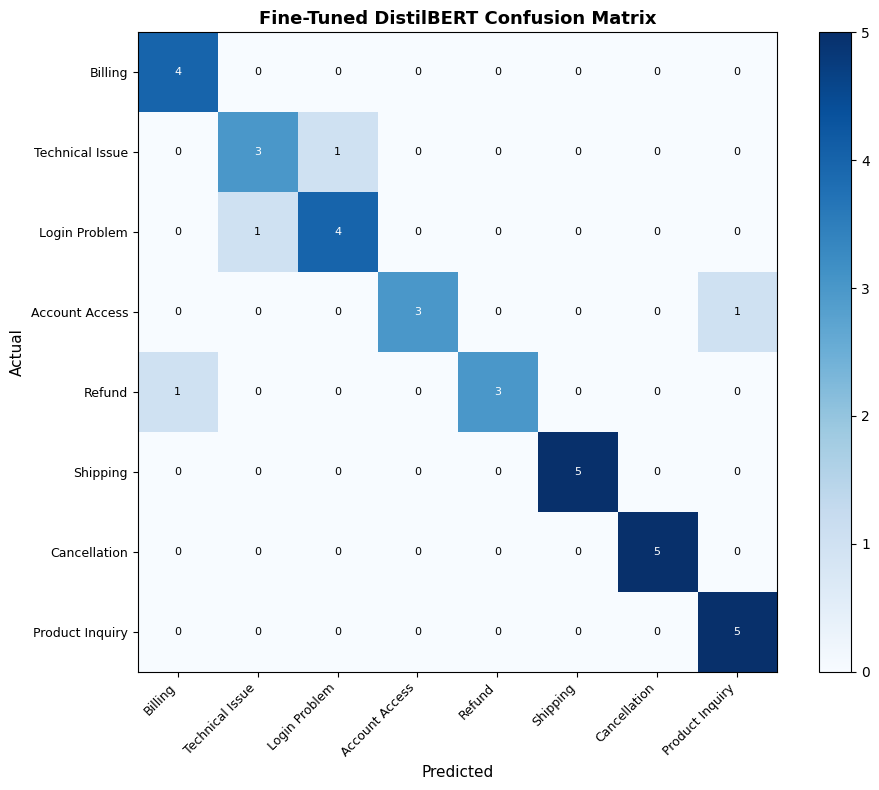

In [30]:
# ── Fine-Tuned Confusion Matrix ─────────────────────────────────────────────
plot_confusion_matrix(ft_true, ft_preds, "Fine-Tuned DistilBERT Confusion Matrix")

In [31]:
# Performance Comparison
# ── Comparison Table ────────────────────────────────────────────────────────
# Create dictionary with all metrics for each approach
comparison_data = {
    "Approach"        : ["Zero-Shot", "Few-Shot", "Fine-Tuned"],  # Method names
    "Model"           : ["bart-large-mnli", "bart-large-mnli + prompts", "distilbert-base-uncased"],  # Underlying models
    "Accuracy"        : [round(zs_acc,4),  round(fs_acc,4),  round(ft_acc,4)],   # Overall accuracy
    "F1-Score"        : [round(zs_f1,4),   round(fs_f1,4),   round(ft_f1,4)],    # Weighted F1-score
    "Precision"       : [round(zs_prec,4), round(fs_prec,4), round(ft_prec,4)],  # Weighted precision
    "Recall"          : [round(zs_rec,4),  round(fs_rec,4),  round(ft_rec,4)],   # Weighted recall
    "Inference (s)"   : [round(zs_time,1), round(fs_time,1), round(ft_eval_time,1)],  # Total test set inference time
    "Needs Training?" : ["No", "No", "Yes"],  # Training requirement indicator
}

# Convert to pandas DataFrame for clean tabular display
df_comparison = pd.DataFrame(comparison_data)

# Print formatted comparison table
print("\n" + "="*80)
print("                    📊 PERFORMANCE COMPARISON TABLE")
print("="*80)
print(df_comparison.to_string(index=False))  # index=False removes row numbers
print("="*80)


                    📊 PERFORMANCE COMPARISON TABLE
  Approach                     Model  Accuracy  F1-Score  Precision  Recall  Inference (s) Needs Training?
 Zero-Shot           bart-large-mnli    0.6944    0.6593     0.8285  0.6944          200.1              No
  Few-Shot bart-large-mnli + prompts    0.5833    0.5805     0.6894  0.5833          238.6              No
Fine-Tuned   distilbert-base-uncased    0.8889    0.8877     0.8991  0.8889            6.0             Yes


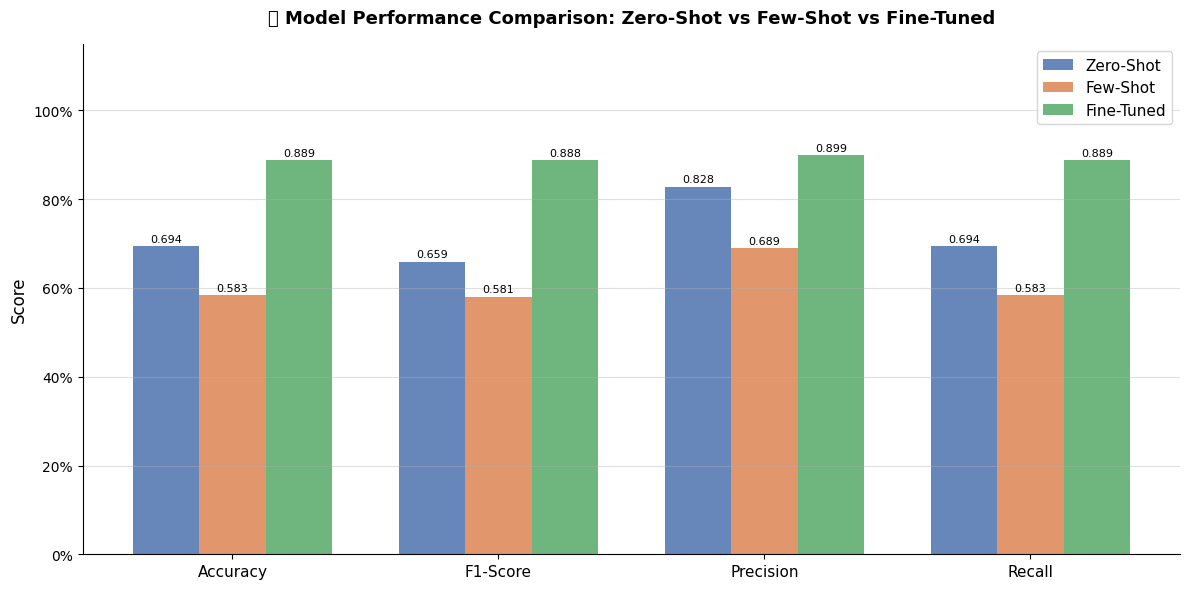


💡 Key Insights:
   • Zero-Shot  : No training needed but lower accuracy. Great for cold-start scenarios.
   • Few-Shot   : Slight improvement via richer label descriptions. Still no training.
   • Fine-Tuned : Highest accuracy. Best for production when labeled data is available.


In [32]:
# ── Comparison Bar Chart ────────────────────────────────────────────────────
# Define metrics to compare and collect values for each approach
metrics   = ['Accuracy', 'F1-Score', 'Precision', 'Recall']  # Evaluation metrics
zs_vals   = [zs_acc,  zs_f1,  zs_prec,  zs_rec]  # Zero-shot values
fs_vals   = [fs_acc,  fs_f1,  fs_prec,  fs_rec]  # Few-shot values
ft_vals   = [ft_acc,  ft_f1,  ft_prec,  ft_rec]  # Fine-tuned values

# Setup bar chart positions
x = np.arange(len(metrics))  # Base positions: [0, 1, 2, 3]
w = 0.25  # Width of each bar (ensures bars don't overlap)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Create grouped bars (shift each group left/right to avoid overlap)
b1 = ax.bar(x - w, zs_vals, w, label='Zero-Shot',  color='#4C72B0', alpha=0.85)  # Left group
b2 = ax.bar(x,     fs_vals, w, label='Few-Shot',   color='#DD8452', alpha=0.85)  # Middle group
b3 = ax.bar(x + w, ft_vals, w, label='Fine-Tuned', color='#55A868', alpha=0.85)  # Right group

# Add numeric labels on top of each bar
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()  # Get bar height (metric value)
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,  # Position above bar
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)  # Format to 3 decimals

# Configure axes labels and title
ax.set_ylabel('Score', fontsize=12)
ax.set_title('🏆 Model Performance Comparison: Zero-Shot vs Few-Shot vs Fine-Tuned',
             fontsize=13, fontweight='bold', pad=15)

# Configure x-axis ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)

# Set y-axis limits and formatting
ax.set_ylim(0, 1.15)  # Add headroom above bars (max 1.0 + padding)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))  # Convert 0.85 → 85%

# Add legend and grid
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)  # Light horizontal grid lines

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Print actionable insights from the comparison
print("\n💡 Key Insights:")
print("   • Zero-Shot  : No training needed but lower accuracy. Great for cold-start scenarios.")
print("   • Few-Shot   : Slight improvement via richer label descriptions. Still no training.")
print("   • Fine-Tuned : Highest accuracy. Best for production when labeled data is available.")

In [33]:
# Gradio Deployment App
import gradio as gr

# ── Unified Prediction Function for App ────────────────────────────────────
def predict_ticket(ticket_text: str, approach: str) -> str:
    """Route ticket to selected approach and return formatted predictions."""
    if not ticket_text.strip():
        return "⚠️ Please enter a support ticket."

    clean = clean_text(ticket_text)  # Preprocess input (lowercase, remove special chars)

    # Call appropriate prediction function based on user selection
    if approach == "Zero-Shot":
        result = zero_shot_predict(clean, top_k=3)
    elif approach == "Few-Shot":
        result = few_shot_predict(clean, top_k=3)
    else:  # Fine-Tuned
        result = ft_predict_top3(clean, top_k=3)

    # Build formatted output with visual progress bars
    output = f"### 🏷️ Top-3 Predicted Tags — [{approach}]\n\n"
    medals = ["🥇", "🥈", "🥉"]  # Medal emojis for ranking
    for i, (lbl, score) in enumerate(zip(result['top_labels'], result['top_scores'])):
        bar_len = int(score * 30)  # Scale confidence to 30-character bar
        bar = "█" * bar_len + "░" * (30 - bar_len)  # Solid bar for confidence, dots for remainder
        output += f"{medals[i]} **{lbl}**\n`{bar}` {score:.1%}\n\n"  # Show percentage

    output += f"---\n✅ **Final Tag:** `{result['predicted']}`"  # Best prediction
    return output

# ── Gradio Interface ────────────────────────────────────────────────────────
# Pre-defined examples for one-click testing
examples = [
    ["I was charged twice this month and I need a refund urgently.", "Fine-Tuned"],
    ["The app crashes every time I open it on my Android phone.", "Zero-Shot"],
    ["I forgot my password and the reset email never arrived.", "Few-Shot"],
    ["What is the difference between the basic and enterprise plan?", "Fine-Tuned"],
    ["My package has been stuck in transit for 2 weeks.", "Zero-Shot"],
]

# Build Gradio interface with soft theme
with gr.Blocks(
    theme=gr.themes.Soft(),
    title="Auto Tagging Support Tickets"
) as demo_app:

    # Header section with description
    gr.Markdown("""
    # 🎫 Auto Tagging Support Tickets Using LLM
    **Classify customer support tickets into categories automatically**
    Built with: `facebook/bart-large-mnli` + `distilbert-base-uncased`
    """)

    # Two-column layout: input controls (left) and output display (right)
    with gr.Row():
        with gr.Column(scale=2):  # Input column (wider)
            ticket_input = gr.Textbox(
                label="📝 Enter Support Ticket",
                placeholder="e.g. I was charged twice and need a refund...",
                lines=4
            )
            approach_input = gr.Radio(
                choices=["Zero-Shot", "Few-Shot", "Fine-Tuned"],
                value="Fine-Tuned",  # Default to best-performing approach
                label="🔧 Classification Approach"
            )
            predict_btn = gr.Button("🔍 Predict Tags", variant="primary")

        with gr.Column(scale=3):  # Output column (narrower)
            output_box = gr.Markdown(label="🏷️ Prediction Results")

    # Connect button click to prediction function
    predict_btn.click(
        fn=predict_ticket,
        inputs=[ticket_input, approach_input],
        outputs=output_box
    )

    # Add example inputs for users to try
    gr.Examples(examples=examples, inputs=[ticket_input, approach_input])

    # Footer with category list
    gr.Markdown("""
    ---
    **Categories:** Billing | Technical Issue | Login Problem | Account Access
    | Refund | Shipping | Cancellation | Product Inquiry
    """)

# Launch the app with public share link (valid for 72 hours)
print("✅ Gradio app ready — launching...")
demo_app.launch(share=True, debug=False)

✅ Gradio app ready — launching...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a7708614ff29444d78.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
